In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Load Dataset

In [1168]:
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/wine_development.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
df = pd.read_csv(github_url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4157 entries, 0 to 4156
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4157 non-null   float64
 1   volatile acidity      4157 non-null   float64
 2   citric acid           4157 non-null   float64
 3   residual sugar        4157 non-null   float64
 4   chlorides             4157 non-null   float64
 5   free sulfur dioxide   4157 non-null   float64
 6   total sulfur dioxide  4157 non-null   float64
 7   density               4157 non-null   float64
 8   pH                    4157 non-null   float64
 9   sulphates             4157 non-null   float64
 10  alcohol               4157 non-null   float64
 11  quality               4157 non-null   int64  
 12  color                 4157 non-null   object 
 13  wine_id               4157 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 454.8+ KB


In [1169]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color,wine_id
0,5.8,0.31,0.32,4.5,0.024,28.0,94.0,0.98906,3.25,0.52,13.7,7,white,1198
1,6.3,0.13,0.42,1.1,0.043,63.0,146.0,0.99066,3.13,0.72,11.2,7,white,3409
2,8.2,0.30,0.44,12.4,0.043,52.0,154.0,0.99452,3.04,0.33,12.0,6,white,4789
3,9.4,0.17,0.55,1.6,0.049,14.0,94.0,0.99490,3.02,0.61,10.3,6,white,3054
4,5.3,0.30,0.16,4.2,0.029,37.0,100.0,0.99050,3.30,0.36,11.8,8,white,2812


In [1170]:
# Dropping irrelevant columns and target variable

X = df.drop(columns=["wine_id"])
y = X.pop("color")

# checking null values of predictors
X.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

<Axes: title={'center': 'Class distribution'}, xlabel='color'>

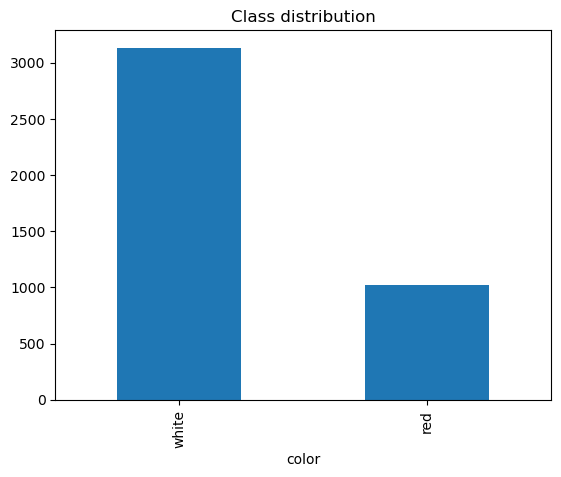

In [1171]:
# Visualizing class distribution
y.value_counts(normalize=True)
y.value_counts().plot(kind="bar", title="Class distribution")

In [1172]:
# descriptive statistics of predictors
display(X.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4157.0,7.21,1.30,3.90,6.40,7.00,7.70,15.90
volatile acidity,4157.0,0.34,0.17,0.08,0.23,0.29,0.40,1.58
citric acid,4157.0,0.32,0.14,0.00,0.25,0.31,0.39,1.66
residual sugar,4157.0,5.40,4.73,0.60,1.80,3.00,8.10,65.80
chlorides,4157.0,0.06,0.03,0.01,0.04,0.05,0.06,0.61
free sulfur dioxide,4157.0,30.42,17.99,1.00,17.00,29.00,41.00,289.00
total sulfur dioxide,4157.0,115.48,56.85,6.00,77.00,118.00,155.00,440.00
density,4157.0,0.99,0.00,0.99,0.99,0.99,1.00,1.04
pH,4157.0,3.22,0.16,2.74,3.11,3.21,3.32,3.90
sulphates,4157.0,0.53,0.15,0.22,0.43,0.51,0.60,1.95


### Splitting Data

In [1173]:
# Splitting the data into training and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify= y
)

In [1174]:
# print shapes of the splits
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)



Train shape: (3325, 12) (3325,)
Test shape: (832, 12) (832,)


In [1175]:
# Creating a table to show class distribution in train and test sets
dist_table = pd.concat(
    [
        y_train.value_counts(),
        y_test.value_counts()
    ],
    axis=1,
    keys=["Train", "Test"]
)

dist_table = dist_table.fillna(0).astype(int)

dist_table = dist_table.reset_index()
dist_table.columns = ["Color", "Train", "Test"]
display(dist_table.style.hide(axis="index"))


Color,Train,Test
white,2507,627
red,818,205


### Creating Null Model

In [1176]:
# Establishing a baseline with DummyClassifier
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Null Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Null F1:", f1_score(y_test, y_pred_dummy, average="macro"))

Null Accuracy: 0.7536057692307693
Null F1: 0.4297464016449623


Text(0.5, 1.0, 'Confusion Matrix - Null Model')

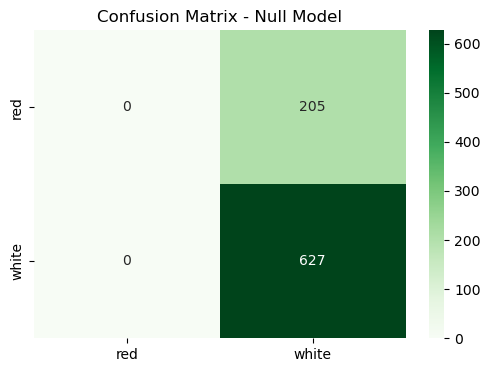

In [1177]:
conf_matrix = confusion_matrix(y_test, y_pred_dummy)    

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=dummy.classes_,
    columns=dummy.classes_
)   

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Null Model")


In [1178]:
# Detailed classification report for the baseline model
report_dict = classification_report(
    y_test,
    y_pred_dummy,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T

display(report_df.round(2))

c:\Users\sassa\miniconda3\envs\ASDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sassa\miniconda3\envs\ASDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sassa\miniconda3\envs\ASDA\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

,precision,recall,f1-score,support
red,0.00,0.00,0.00,205.00
white,0.75,1.00,0.86,627.00
accuracy,0.75,0.75,0.75,0.75
macro avg,0.38,0.50,0.43,832.00
weighted avg,0.57,0.75,0.65,832.00


### Linear SVM

In [1179]:
# Training and evaluating a Linear SVM model

linear_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0, random_state=42))
])

linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Linear SVM F1:", f1_score(y_test, y_pred_linear, average="macro"))

Linear SVM Accuracy: 0.9951923076923077
Linear SVM F1: 0.9935270548877737


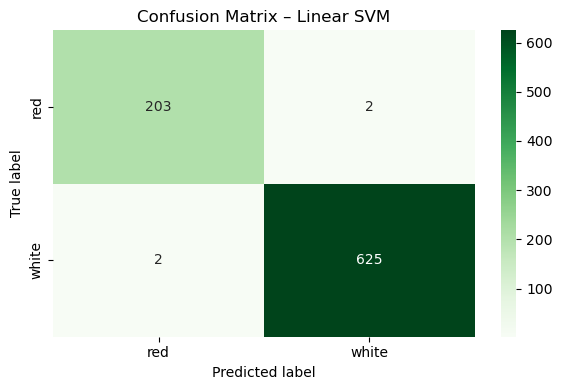

In [1180]:
# Confusion matrix for Linear SVM
conf_matrix = confusion_matrix(y_test, y_pred_linear)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=linear_svm.classes_,
    columns=linear_svm.classes_
)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix – Linear SVM")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


In [1181]:
# Detailed classification report for Linear SVM
report_dict_linear = classification_report(
    y_test,
    y_pred_linear,
    output_dict=True
)

report_df_linear = pd.DataFrame(report_dict_linear).T

display(report_df_linear.round(2))

,precision,recall,f1-score,support
red,0.99,0.99,0.99,205.0
white,1.00,1.00,1.00,627.0
accuracy,1.00,1.00,1.00,1.0
macro avg,0.99,0.99,0.99,832.0
weighted avg,1.00,1.00,1.00,832.0


### Optimizing Linear SVM model parameters through GridSearch

In [1182]:
# Parameter tuning with GridSearchCV for Linear SVM
pipe_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", random_state=42))
])

parameter_grid = {
    "svc__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_linear = GridSearchCV(
    estimator=pipe_linear,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
grid_linear.fit(X_train, y_train)
best_linear = grid_linear.best_estimator_

print("Best parameter:", grid_linear.best_params_)
print("Best F1:", grid_linear.best_score_)

Best parameter: {'svc__C': 1}
Best F1: 0.9922834597269905


In [1183]:
# Summarizing cross-validation results
results = pd.DataFrame(grid_linear.cv_results_)
summary = results[["param_svc__C", "mean_test_score", "std_test_score"]].copy()
summary.rename(columns={
    "param_svc__C": "C",
    "mean_test_score": "CV_F1_mean",
    "std_test_score": "CV_F1_std"
}, inplace=True)

summary.sort_values("CV_F1_mean", ascending=False)


,C,CV_F1_mean,CV_F1_std
3,1.000,0.992283,0.003503
2,0.100,0.991484,0.002980
4,10.000,0.991477,0.003716
5,100.000,0.991474,0.002699
6,1000.000,0.991474,0.002699
1,0.010,0.988661,0.002057
0,0.001,0.982878,0.003380


### Trying out RBF 

In [1184]:
# Training and evaluating an RBF SVM model

rbf_svm = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)

print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("RBF SVM F1:", f1_score(y_test, y_pred_rbf, average="macro"))


RBF SVM Accuracy: 0.9963942307692307
RBF SVM F1: 0.9951372992139024


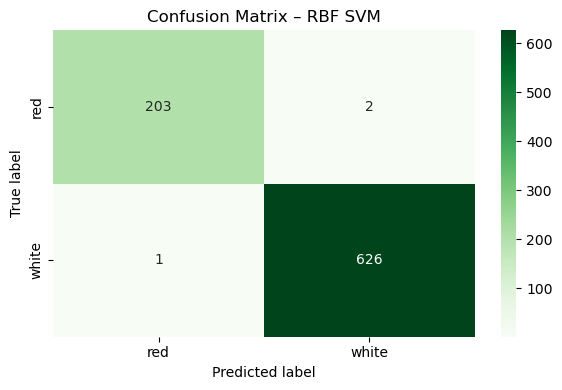

In [1185]:
# Confusion matrix for RBF SVM
conf_matrix = confusion_matrix(y_test, y_pred_rbf)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=rbf_svm.classes_,
    columns=rbf_svm.classes_
)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix – RBF SVM")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


In [1186]:
# Detailed classification report for RBF SVM
report_dict_rbf = classification_report(
    y_test,
    y_pred_rbf,
    output_dict=True
)

report_df_rbf = pd.DataFrame(report_dict_rbf).T
display(report_df_rbf.round(2))

,precision,recall,f1-score,support
red,1.0,0.99,0.99,205.0
white,1.0,1.00,1.00,627.0
accuracy,1.0,1.00,1.00,1.0
macro avg,1.0,0.99,1.00,832.0
weighted avg,1.0,1.00,1.00,832.0


### Optimizing RBF SVM model parameters through GridSearch

In [1187]:
# Parameter tuning with GridSearchCV for RBF SVM
pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", random_state=42))
])

parameter_grid = {
    "svc__C": [0.1, 1, 10, 100, 1000],
    "svc__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rbf = GridSearchCV(
    estimator=pipe_rbf,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_rbf.fit(X_train, y_train)
best_rbf = grid_rbf.best_estimator_

print("Best parameter:", grid_rbf.best_params_)
print("Best F1:", grid_rbf.best_score_)

Best parameter: {'svc__C': 100, 'svc__gamma': 0.01}
Best F1: 0.9939021729974664


In [1188]:
# Summarizing cross-validation results for RBF SVM
results = pd.DataFrame(grid_rbf.cv_results_)
summary = results[["param_svc__C", "param_svc__gamma","mean_test_score", "std_test_score"]].copy()
summary.rename(columns={
"param_svc__C": "C",
    "param_svc__gamma": "gamma",
    "mean_test_score": "CV_F1_mean",
    "std_test_score": "CV_F1_std"
}, inplace=True)

# Sort by best CV performance
summary = summary.sort_values("CV_F1_mean", ascending=False)

summary.reset_index(drop=True, inplace=True)

summary

,C,gamma,CV_F1_mean,CV_F1_std
0,100.0,0.01,0.993902,0.002864
1,1000.0,0.001,0.993897,0.003399
2,10.0,0.01,0.993497,0.002359
3,100.0,0.001,0.992691,0.002753
4,1.0,scale,0.992676,0.003301
5,1.0,auto,0.992676,0.003301
6,10.0,scale,0.992672,0.002079
7,10.0,0.1,0.992672,0.002079
8,10.0,auto,0.992672,0.002079
9,1.0,0.1,0.992267,0.002690


### Choosing linear SVM as the final model

In [1189]:
final_model = best_linear
final_model.fit(X, y)

,steps,"[('scaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'


In [1190]:
svc = final_model.named_steps["svc"]
coef = svc.coef_.ravel()

feature_importance = (
    pd.Series(np.abs(coef), index=X.columns)
      .sort_values(ascending=False)
)

feature_importance

density                 2.321225
residual sugar          1.888663
total sulfur dioxide    1.201288
alcohol                 0.844574
free sulfur dioxide     0.435218
volatile acidity        0.383402
citric acid             0.309800
chlorides               0.278375
sulphates               0.202491
pH                      0.163116
quality                 0.151986
fixed acidity           0.121949
dtype: float64

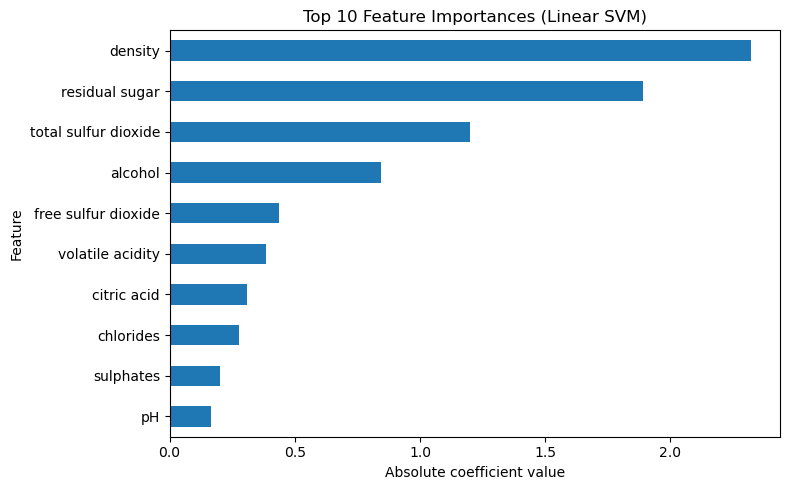

In [1191]:
plt.figure(figsize=(8,5))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances (Linear SVM)")
plt.xlabel("Absolute coefficient value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [1192]:
signed_importance = pd.Series(coef, index=X.columns).sort_values()
signed_importance.head(), signed_importance.tail()

(density               -2.321225
 alcohol               -0.844574
 free sulfur dioxide   -0.435218
 volatile acidity      -0.383402
 chlorides             -0.278375
 dtype: float64,
 fixed acidity           0.121949
 pH                      0.163116
 citric acid             0.309800
 total sulfur dioxide    1.201288
 residual sugar          1.888663
 dtype: float64)

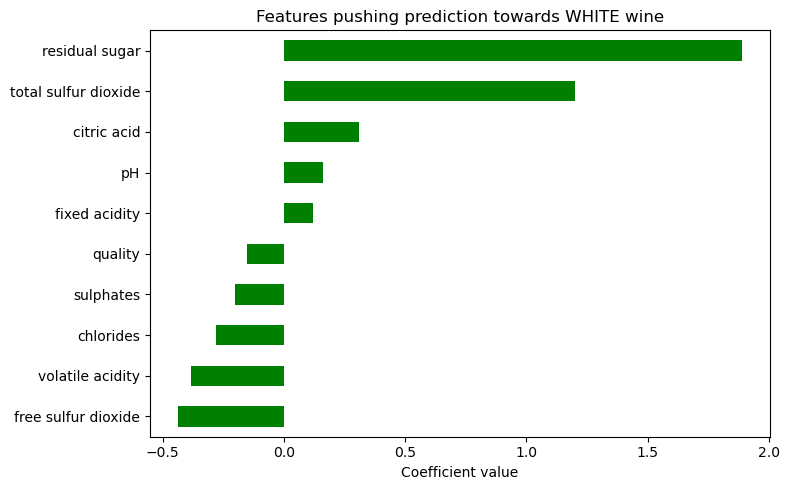

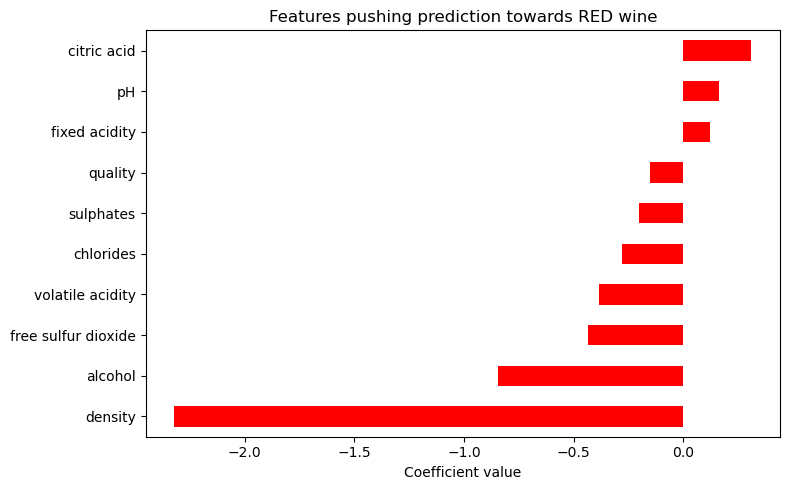

In [1193]:
signed_importance = pd.Series(coef, index=X.columns).sort_values()

plt.figure(figsize=(8,5))
signed_importance.tail(10).plot(kind="barh", color="green")
plt.title("Features pushing prediction towards WHITE wine")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
signed_importance.head(10).plot(kind="barh", color="red")
plt.title("Features pushing prediction towards RED wine")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()


### Add visualizations (like PCA/scatter plot as per guidelines)

### Checking Model Performance on Holdout data

### Load Holdout X and Y

In [1194]:
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/wine_holdout_X.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
X_df = pd.read_csv(github_url)
X_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1040 non-null   float64
 1   volatile acidity      1040 non-null   float64
 2   citric acid           1040 non-null   float64
 3   residual sugar        1040 non-null   float64
 4   chlorides             1040 non-null   float64
 5   free sulfur dioxide   1040 non-null   float64
 6   total sulfur dioxide  1040 non-null   float64
 7   density               1040 non-null   float64
 8   pH                    1040 non-null   float64
 9   sulphates             1040 non-null   float64
 10  alcohol               1040 non-null   float64
 11  quality               1040 non-null   int64  
 12  wine_id               1040 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 105.8 KB


In [1195]:
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/wine_holdout_y.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
X_df = pd.read_csv(github_url)
X_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   wine_id  1040 non-null   int64 
 1   color    1040 non-null   object
dtypes: int64(1), object(1)
memory usage: 16.4+ KB
